### Writing down what Lohani does

Combination of pure and mixed states generated in Lohanis

Will use only mixed states here for simplicity - generated using the Ginibre ensemble 
$$
G = N(0,1) + i\,N(0,1), \quad 
\rho = \frac{G G^{\dagger}}{\mathrm{Tr}(G G^{\dagger})}
$$

Noise generated by rotating each projector by a random unitary with angles drawn from gaussian with mean of zero (small misalignments)

36 distinct projectors are used in Lohanis paper:

$$
\begin{aligned}
|H\rangle &= 
\begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad 
|V\rangle = 
\begin{bmatrix} 0 \\ 1 \end{bmatrix}, \\
|D\rangle &= \tfrac{1}{\sqrt{2}} (|H\rangle + |V\rangle), \quad 
|A\rangle = \tfrac{1}{\sqrt{2}} (|H\rangle - |V\rangle), \\
|R\rangle &= \tfrac{1}{\sqrt{2}} (|H\rangle + i|V\rangle), \quad 
|L\rangle = \tfrac{1}{\sqrt{2}} (|H\rangle - i|V\rangle).
\end{aligned}
$$

The corresponding projectors are:

$$
h = |H\rangle\langle H|,\quad
v = |V\rangle\langle V|,\quad
d = |D\rangle\langle D|,\quad
a = |A\rangle\langle A|,\quad
r = |R\rangle\langle R|,\quad
l = |L\rangle\langle L|.
$$


The full two-qubit tomography measurement matrix \( P \) used in simulation is:

$$
P =
\begin{bmatrix}
h\!\otimes\!h & h\!\otimes\!v & v\!\otimes\!v & v\!\otimes\!h & v\!\otimes\!r & v\!\otimes\!l \\
h\!\otimes\!l & h\!\otimes\!r & h\!\otimes\!d & h\!\otimes\!a & v\!\otimes\!a & v\!\otimes\!d \\
a\!\otimes\!d & a\!\otimes\!a & d\!\otimes\!a & d\!\otimes\!d & d\!\otimes\!r & d\!\otimes\!l \\
a\!\otimes\!l & a\!\otimes\!r & a\!\otimes\!h & a\!\otimes\!v & d\!\otimes\!v & d\!\otimes\!h \\
r\!\otimes\!h & r\!\otimes\!v & l\!\otimes\!v & l\!\otimes\!h & l\!\otimes\!r & l\!\otimes\!l \\
r\!\otimes\!l & r\!\otimes\!r & r\!\otimes\!d & r\!\otimes\!a & l\!\otimes\!a & l\!\otimes\!d
\end{bmatrix}
$$


Each projector $ P_{ij} $ acts on the 2-qubit Hilbert space as:
$
M_{ij} = \mathrm{Tr}(\rho\,P_{ij}),
$
producing one of the 36 tomographic measurement probabilities.

CNN used not standard NN

Outputs 16 real numbers that are arranged as lower triangular tau matrix
Can get desnity matrix back using
$$
\rho_{\text{pred}} = \frac{\tau_{\text{pred}}^{\dagger} \tau_{\text{pred}}}
{\mathrm{Tr}(\tau_{\text{pred}}^{\dagger} \tau_{\text{pred}})}
$$

(Haven't used this method here though)

NN process

- simulate noisy measurements from $ P $
- feed 6x6 to the CNN
- CNN outputs tau matrix
- compute $ \rho $ from this 
- compare predicted and true rho for fidelity
- train CNN

Repeated with different training dataset sizes to see how fidelity scales

Max pooling: downsample feature maps by taking maximum value in each small region - focuses on dominant features
Dropout: randomly turns off a fraction of neurons to prevent overfitting

^^ interesting techniques

Kernel: scans over input (2x2 used)
Stride: how far filter moves (1 used)
Feature maps: num of filters applied (25 used)
Zero padding: adds zeros at eaches so dimensions are consistent
ReLU used

fully connected layers with 720 and 450 neurons

tau matrix used as output to ensure positive semidefinite and normalised

### 6x6 Projector matrix P

In [1]:
import numpy as np
seed = 42
np.random.seed(seed)

# Single-qubit basis states
H = np.array([[1.0], [0.0]], dtype=complex)
V = np.array([[0.0], [1.0]], dtype=complex)

D = (H + V) / np.sqrt(2)
A = (H - V) / np.sqrt(2)
R = (H + 1j*V) / np.sqrt(2)
L = (H - 1j*V) / np.sqrt(2)

def proj(ket):
    return ket @ ket.conj().T

h = proj(H)
v = proj(V)
d = proj(D)
a = proj(A)
r = proj(R)
l = proj(L)

projs = [h, v, d, a, r, l]  # List of projection matrices

In [2]:
P = np.empty((6,6), dtype=object)

for i in range(6):
    for j in range(6):
        P[i,j] = np.kron(projs[i], projs[j])

### Generating Ginibre State and finding noisy measurements

In [3]:
def random_mixed_state():
    G = (np.random.normal(size=(4, 4)) 
         + 1j * np.random.normal(size=(4, 4)))
    rho = G @ G.conj().T
    rho /= np.trace(rho)
    return rho

In [4]:
# Lohani samples Euler angles from N(0, sigma)
def noisy_unitary(sigma):
    theta, phi, zeta = np.random.normal(0, sigma, 3)
    U = np.array([
        [np.exp(1j*phi/2)*np.cos(theta), -1j*np.exp(1j*zeta)*np.sin(theta)],
        [-1j*np.exp(-1j*zeta)*np.sin(theta), np.exp(-1j*phi/2)*np.cos(theta)]
    ], dtype=complex)
    return U

def rotate_projector(P, sigma):
    U1 = noisy_unitary(sigma)
    U2 = noisy_unitary(sigma)
    U = np.kron(U1, U2)
    return U @ P @ U.conj().T

In [5]:
def measure_state(rho, P, sigma):

    M = np.empty((6,6), dtype=float)
    for i in range(6):
        for j in range(6):
            P_noisy = rotate_projector(P[i,j], sigma)
            M[i, j] = np.real(np.trace(rho @ P_noisy))
    return M

### Generate N random states + their measurements + targets

In [6]:
def generate_dataset(N, P, sigma):
    X = np.zeros((N, 36), dtype=np.float32)
    Y = np.zeros((N, 32), dtype=np.float32)

    for k in range(N):
        rho = random_mixed_state()
        M = measure_state(rho, P, sigma)
        X[k] = M.reshape(-1)

        rho_flat = rho.reshape(-1)
        Y[k, :16] = np.real(rho_flat)
        Y[k, 16:] = np.imag(rho_flat) # imag parts seperate, so 32 outputs, 16 for real, 16 for imag

    return X, Y

In [7]:
# We also need a function to find fidelity between two density matrices
from scipy.linalg import sqrtm

def fidelity_from_output(pred, true):
    pred_rho = pred[:16] + 1j * pred[16:]
    true_rho = true[:16] + 1j * true[16:]

    pred_rho = pred_rho.reshape(4, 4)
    true_rho = true_rho.reshape(4, 4)

    pred_rho = (pred_rho + pred_rho.conj().T) / 2
    true_rho = (true_rho + true_rho.conj().T) / 2
    pred_rho /= np.trace(pred_rho)
    true_rho /= np.trace(true_rho)

    sqrt_true = sqrtm(true_rho)
    inner = sqrt_true @ pred_rho @ sqrt_true
    F = np.real(np.trace(sqrtm(inner)) ** 2)
    return float(np.clip(F, 0, 1))

### Start with standard sequential NN to test

In [8]:
# Implement a fidelity loss option in torch to see if performs better than MSE
import torch

def _rho_from_vec(x): # Getting density matrix from NN output

    re = x[:, :16]
    im = x[:, 16:]
    rho = torch.complex(re, im).reshape(-1, 4, 4)
    rho = 0.5*(rho + rho.conj().transpose(-2, -1))
    tr = torch.real(torch.diagonal(rho, dim1=-2, dim2=-1).sum(-1, keepdim=True))
    return rho / (tr.unsqueeze(-1) + 1e-8)

def fidelity_loss(pred, target): # Find fidelity loss between predicted and target density matrices

    rho_p = _rho_from_vec(pred)
    rho_t = _rho_from_vec(target)

    evals_t, vecs_t = torch.linalg.eigh(rho_t)
    diag_sqrt = torch.diag_embed(torch.sqrt(torch.clamp(evals_t, min=0))).to(torch.cfloat)
    sqrt_t    = vecs_t @ diag_sqrt @ vecs_t.conj().transpose(-2, -1)

    inner = sqrt_t @ rho_p @ sqrt_t
    evals_inner, _ = torch.linalg.eigh(inner)
    F = (torch.sqrt(torch.clamp(evals_inner, min=0)).sum(dim=-1))**2

    return 1 - F.mean()

In [9]:
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(seed)


def make_model():
    model = nn.Sequential(
        nn.Linear(36, 720),
        nn.ReLU(),
        nn.Linear(720, 450),
        nn.ReLU(),
        nn.Dropout(0.5),   # reduce overfitting
        nn.Linear(450, 32)  # 32 = 16 Re + 16 Im of rho
    )
    return model


#### NOTE: currently ouputting directly to rho not tau - change later - 16 outputs and chagne fidelity and true output

### Implementing Stokes Reconstruction

The goal of Stokes reconstruction is to recover the density matrix $ \rho $ directly from the measured tomography vector $ M $ without using optimisation or machine learning.

For each projector $ P_k $ (out of the 36), the measurement probability satisfies

$$
M_k = \mathrm{Tr}(\rho P_k).
$$

Using the identity

$$
\mathrm{Tr}(\rho P_k) = \mathrm{vec}(P_k^T)^\dagger\, \mathrm{vec}(\rho),
$$

we can write all 36 measurement equations in matrix form:

$$
M = A \, \mathrm{vec}(\rho),
$$

where:

- $ M $ is the 36-dimensional measurement vector,  
- $ \mathrm{vec}(\rho) $ is the 16-dimensional vectorised density matrix,  
- $ A $ is a $36 \times 16$ matrix whose rows are $ \mathrm{vec}(P_k^T)^\dagger $.

Reconstructing $ \rho $ is then a simple **least-squares problem**:

$$
\mathrm{vec}(\rho_{\text{Stokes}}) 
= A^{+} M,
$$

where $ A^{+} $ is the Moore–Penrose pseudoinverse of $ A $.

Finally, the reconstructed matrix is reshaped to $ 4 \times 4 $, symmetrised, and normalised to ensure

$$
\rho_{\text{Stokes}}
= \frac{1}{\mathrm{Tr}(\rho_{\text{Stokes}})}
\frac{\rho_{\text{Stokes}} + \rho_{\text{Stokes}}^\dagger}{2}.
$$

This linear inversion method provides a fast, classical baseline for evaluating the performance of machine-learning-based reconstructions.


In [10]:
# build A such that M = A @ vec(rho)
# building the linear system

def build_stokes_matrix(P):
    
    A = np.zeros((36, 16), dtype=complex)
    idx = 0
    for i in range(6):
        for j in range(6):
            # Tr(rho P) = vec(P^T) · vec(rho)
            A[idx, :] = P[i, j].T.reshape(-1)
            idx += 1
    return A

A_stokes = build_stokes_matrix(P)


In [11]:
# reconstructing via stokes using the measurements

def stokes_reconstruct(M_flat, A=A_stokes):

    # Solve A x ≈ M in least-squares sense
    x, *_ = np.linalg.lstsq(A, M_flat.astype(complex), rcond=None)
    rho_est = x.reshape(4, 4)

    # Make it Hermitian and trace-1 (basic physical cleanup)
    rho_est = (rho_est + rho_est.conj().T) / 2
    rho_est /= np.trace(rho_est)
    return rho_est

In [12]:
def train_and_eval_for_N(N, P, sigma, loss_type, n_epochs=200, lr=1e-3):

    np.random.seed(seed)
    torch.manual_seed(seed)

    X, Y = generate_dataset(N, P, sigma)
    
    split = int(0.8 * N)
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]
    
    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    Y_train_t = torch.from_numpy(Y_train.astype(np.float32))
    X_test_t  = torch.from_numpy(X_test.astype(np.float32))

    model = make_model()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    
    def loss_fn(pred, target):
        if loss_type == "mse":
            return mse_loss(pred, target)
        elif loss_type == "fidelity":
            return fidelity_loss(pred, target)
        else:
            raise ValueError(f"Unknown loss_type: {loss_type}")

    for epoch in range(n_epochs):
        model.train()
        for i in range(0, len(X_train_t), 4):  # mini-batch size 4
            X_batch = X_train_t[i:i+4]
            Y_batch = Y_train_t[i:i+4]
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = loss_fn(pred, Y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t).numpy()   # (N_test, 32)

    fids_nn = []
    fids_stokes = []

    for k in range(len(pred_test)):
       
        f_nn = fidelity_from_output(pred_test[k], Y_test[k])
        fids_nn.append(f_nn)

        true_flat = Y_test[k]
        true_rho = (true_flat[:16] + 1j * true_flat[16:]).reshape(4, 4)
        true_rho = (true_rho + true_rho.conj().T) / 2
        true_rho /= np.trace(true_rho)

        # Stokes reconstruction from measurement vector
        rho_stokes = stokes_reconstruct(X_test[k]) 
        rho_stokes_flat = rho_stokes.reshape(-1)
        rho_stokes_flat = np.concatenate([np.real(rho_stokes_flat),np.imag(rho_stokes_flat)])
        
        fids_stokes.append(fidelity_from_output(rho_stokes_flat, Y_test[k]))

    avg_fid_nn = float(np.mean(fids_nn))
    avg_fid_stokes = float(np.mean(fids_stokes))

    print(f"N={N}, Avg NN fidelity:     {avg_fid_nn:.6e}")
    print(f"N={N}, Avg Stokes fidelity: {avg_fid_stokes:.6e}")

    return avg_fid_nn, avg_fid_stokes


In [13]:
N_list = np.linspace(20, 200, 10, dtype=int)
sigma  = 0.564  # ≈ pi/6

avg_fids_nn = []
avg_fids_nn_fid_loss = []
avg_fids_stokes = []

for N in N_list:
    print(f"\n=== Running experiment for N = {N} ===")
    fid_nn, fid_stokes = train_and_eval_for_N(N, P, sigma, loss_type="mse",  n_epochs=400, lr=1e-3)
    # fid_nn_fid_loss, _ = train_and_eval_for_N(N, P, sigma, loss_type="fidelity", n_epochs=400, lr=1e-3)
    avg_fids_nn.append(fid_nn)
    avg_fids_stokes.append(fid_stokes)
    # avg_fids_nn_fid_loss.append(fid_nn_fid_loss)



=== Running experiment for N = 20 ===
N=20, Avg NN fidelity:     7.157051e-01
N=20, Avg Stokes fidelity: 7.770463e-01

=== Running experiment for N = 40 ===
N=40, Avg NN fidelity:     7.847258e-01
N=40, Avg Stokes fidelity: 8.364168e-01

=== Running experiment for N = 60 ===
N=60, Avg NN fidelity:     7.569169e-01
N=60, Avg Stokes fidelity: 8.388874e-01

=== Running experiment for N = 80 ===
N=80, Avg NN fidelity:     7.697824e-01
N=80, Avg Stokes fidelity: 8.330260e-01

=== Running experiment for N = 100 ===
N=100, Avg NN fidelity:     7.891564e-01
N=100, Avg Stokes fidelity: 8.414331e-01

=== Running experiment for N = 120 ===
N=120, Avg NN fidelity:     7.925008e-01
N=120, Avg Stokes fidelity: 8.494292e-01

=== Running experiment for N = 140 ===
N=140, Avg NN fidelity:     7.783679e-01
N=140, Avg Stokes fidelity: 8.379876e-01

=== Running experiment for N = 160 ===
N=160, Avg NN fidelity:     8.017857e-01
N=160, Avg Stokes fidelity: 8.265851e-01

=== Running experiment for N = 180 

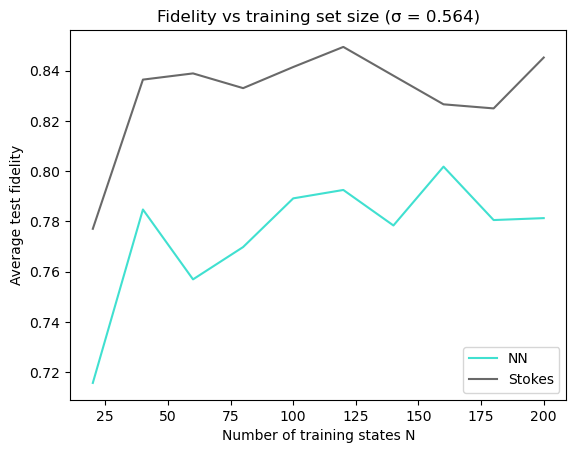

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(N_list, avg_fids_nn, marker='', label='NN', linestyle='-', color='turquoise')
plt.plot(N_list, avg_fids_stokes, marker='', label='Stokes', linestyle='-', color='dimgrey')
plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma})")
plt.grid(False)
plt.legend()
plt.show()

### Defining and trying CNN

In [28]:
import torch.nn.functional as F

def make_cnn_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), # 6x6 grid in
        nn.ReLU(),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # 16 channels go to 32 new filters of 6x6 grids
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),  # shrinks each 6x6 grid to 3x3 grid

        nn.Flatten(),                           # 32 filters * 3x3 grid = 288
        nn.Linear(32 * 3 * 3, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 32)                      # 32 = 16 Re + 16 Im of rho
    )
    return model

In [29]:
def train_and_eval_for_N_cnn(N, P, sigma, loss_type, n_epochs=200, lr=1e-3):

    np.random.seed(seed)
    torch.manual_seed(seed)

    X, Y = generate_dataset(N, P, sigma)
    
    split = int(0.8 * N)
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]
    
    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    Y_train_t = torch.from_numpy(Y_train.astype(np.float32))
    X_test_t  = torch.from_numpy(X_test.astype(np.float32))

    model = make_cnn_model()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
    
    def loss_fn(pred, target):
        if loss_type == "mse":
            return mse_loss(pred, target)
        elif loss_type == "fidelity":
            return fidelity_loss(pred, target)
        else:
            raise ValueError(f"Unknown loss_type: {loss_type}")

    for epoch in range(n_epochs):
        model.train()
        for i in range(0, len(X_train_t), 4):
            X_batch = X_train_t[i:i+4]
            Y_batch = Y_train_t[i:i+4]

            # reshape (batch, 36) -> (batch, 1, 6, 6) for CNN
            X_batch_img = X_batch.view(-1, 1, 6, 6)

            optimizer.zero_grad()
            pred = model(X_batch_img)
            loss = loss_fn(pred, Y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_test_img = X_test_t.view(-1, 1, 6, 6)
        pred_test = model(X_test_img).numpy()   # (N_test, 32)

    fids_cnn = []
    fids_stokes = []

    for k in range(len(pred_test)):

        f_cnn = fidelity_from_output(pred_test[k], Y_test[k])
        fids_cnn.append(f_cnn)

        true_flat = Y_test[k]
        true_rho = (true_flat[:16] + 1j * true_flat[16:]).reshape(4, 4)
        true_rho = (true_rho + true_rho.conj().T) / 2
        true_rho /= np.trace(true_rho)

        rho_stokes = stokes_reconstruct(X_test[k])
        rho_stokes_flat = rho_stokes.reshape(-1)
        rho_stokes_flat = np.concatenate(
            [np.real(rho_stokes_flat), np.imag(rho_stokes_flat)]
        )

        fids_stokes.append(fidelity_from_output(rho_stokes_flat, Y_test[k]))

    avg_fid_cnn    = float(np.mean(fids_cnn))
    avg_fid_stokes = float(np.mean(fids_stokes))

    print(f"N={N}, CNN Avg fidelity:     {avg_fid_cnn:.6e}")
    print(f"N={N}, Stokes Avg fidelity:  {avg_fid_stokes:.6e}")

    return avg_fid_cnn, avg_fid_stokes

In [30]:
### Running CNN experiments over N_list

avg_fids_cnn = []
avg_fids_stokes_cnn = []
avg_fids_cnn_fid_loss = []

for N in N_list:
    print(f"\n=== Running CNN experiment for N = {N} ===")
    fid_cnn, fid_stokes_c = train_and_eval_for_N_cnn(
        N, P, sigma, loss_type="mse", n_epochs=1200, lr=1e-3
    )
    fid_cnn_fid_loss, _ = train_and_eval_for_N_cnn(
        N, P, sigma, loss_type="fidelity", n_epochs=1200, lr=1e-3
    )
    avg_fids_cnn.append(fid_cnn)
    avg_fids_stokes_cnn.append(fid_stokes_c)
    avg_fids_cnn_fid_loss.append(fid_cnn_fid_loss)



=== Running CNN experiment for N = 20 ===
N=20, CNN Avg fidelity:     7.087956e-01
N=20, Stokes Avg fidelity:  7.770463e-01
N=20, CNN Avg fidelity:     5.000000e-01
N=20, Stokes Avg fidelity:  7.770463e-01

=== Running CNN experiment for N = 40 ===
N=40, CNN Avg fidelity:     7.591219e-01
N=40, Stokes Avg fidelity:  8.364168e-01
N=40, CNN Avg fidelity:     6.250000e-01
N=40, Stokes Avg fidelity:  8.364168e-01

=== Running CNN experiment for N = 60 ===
N=60, CNN Avg fidelity:     7.505215e-01
N=60, Stokes Avg fidelity:  8.388874e-01
N=60, CNN Avg fidelity:     7.500000e-01
N=60, Stokes Avg fidelity:  8.388874e-01

=== Running CNN experiment for N = 80 ===
N=80, CNN Avg fidelity:     7.574862e-01
N=80, Stokes Avg fidelity:  8.330260e-01
N=80, CNN Avg fidelity:     8.125000e-01
N=80, Stokes Avg fidelity:  8.330260e-01

=== Running CNN experiment for N = 100 ===
N=100, CNN Avg fidelity:     7.721030e-01
N=100, Stokes Avg fidelity:  8.414331e-01
N=100, CNN Avg fidelity:     6.337896e-01
N=

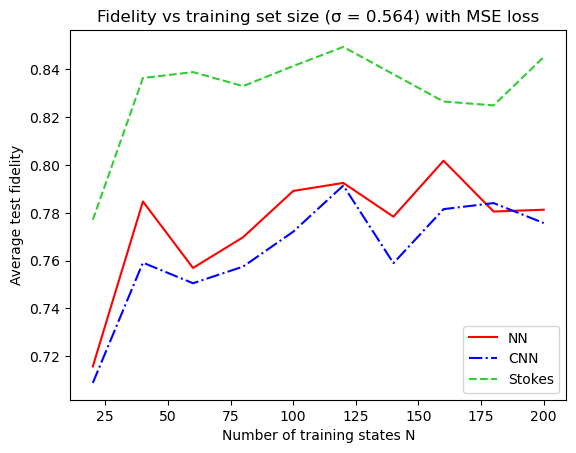

In [31]:
### Comparing NN, CNN and Stokes

plt.figure()
plt.plot(N_list, avg_fids_nn,     label='NN',     linestyle='-', color='red')
plt.plot(N_list, avg_fids_cnn,    label='CNN',    linestyle='-.', color='blue')
plt.plot(N_list, avg_fids_stokes, label='Stokes', linestyle='--', color='limegreen')

plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma}) with MSE loss")
plt.legend()
plt.show()


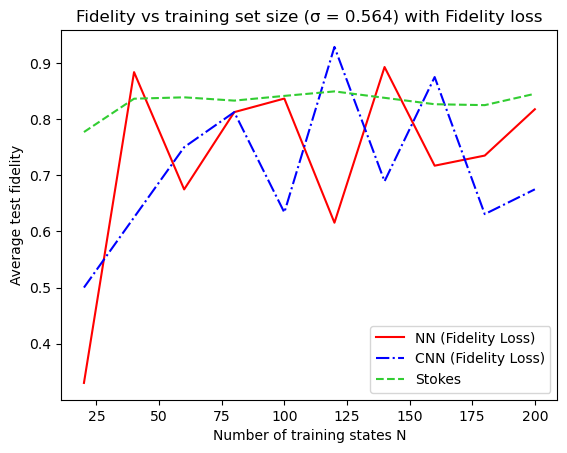

In [32]:
### Comparing the same with fidelity loss

plt.figure()
plt.plot(N_list, avg_fids_nn_fid_loss,     label='NN (Fidelity Loss)',     linestyle='-', color='red')
plt.plot(N_list, avg_fids_cnn_fid_loss,    label='CNN (Fidelity Loss)',    linestyle='-.', color='blue')
plt.plot(N_list, avg_fids_stokes,           label='Stokes', linestyle='--', color='limegreen')

plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma}) with Fidelity loss")
plt.legend()
plt.show()

#### Would it be potentially beneficial to have fidelity as the loss instead of MSE???

### Understanding physical meaning behind nucrypt projectors

From the paper, $ |H\rangle $ is the horizontal polarisation state (1 0) and $ |V\rangle $ is the vertical polarisation state (0 1). 

Exact tomography measurements come from the "Nucrypt entangled photon system"

- **$|H\rangle$**  
  Horizontal polarisation.  
  Physically: photon electric field oscillates horizontally. Measured by a polarising beam-splitter oriented at 0°.

- **$|V\rangle$**  
  Vertical polarisation.  
  Physically: photon electric field oscillates vertically. Measured by PBS at 90°.

- **$|D\rangle = \frac{|H\rangle + |V\rangle}{\sqrt{2}}$**  
  Diagonal polarisation (45°).  
  Physically: linear polarisation rotated +45°. Measured by setting a half-wave plate (HWP) at 22.5° before the PBS.

- **$|A\rangle = \frac{|H\rangle - |V\rangle}{\sqrt{2}}$**  
  Anti-diagonal polarisation (−45°).  
  Physically: linear polarisation rotated −45°. Measured by setting the HWP at −22.5° (or 67.5°) before the PBS.

- **$|R\rangle = \frac{|H\rangle + i|V\rangle}{\sqrt{2}}$**  
  Right-circular polarisation.  
  Physically: electric field rotates clockwise. Measured by placing a quarter-wave plate (QWP) at +45° before the PBS.

- **$|L\rangle = \frac{|H\rangle - i|V\rangle}{\sqrt{2}}$**  
  Left-circular polarisation.  
  Physically: electric field rotates counter-clockwise. Measured by placing a QWP at −45° before the PBS.

A polarising beam splitter (PBS) is an optical device that separates light based on its polarisation.

- It transmits horizontal (H) polarisation.
- It reflects vertical (V) polarisation.

So if a single photon enters a PBS:
- if it is $|H\rangle$ it goes out of one output port,
- if it is $|V\rangle$ it goes out of the other port.

This lets us measure whether the photon is H or V by putting detectors at the two outputs, and different angles can measure different polarisations.

---

A half-wave plate (HWP) is an optical element that rotates the polarisation of a photon.

- A HWP rotates linear polarisation by twice the angle between the incoming polarisation and the plate's “fast axis”.

Key idea:
- Set the HWP to 22.5° → it rotates H/V into D/A.
- Set it to 45° → it swaps H ↔ V.

So a HWP is used to change the basis before the PBS so that the PBS (which only measures H/V) effectively measures in a different basis like D/A.

*Key point - PBS only measures H/V so HWP needed to put into this basis*



see paper - "Robust Multiwavelength All-Fiber Source of Polarization-Entangled Photons With Built-In Analyzer Alignment Signal"


The projector $h \otimes d$ where $h=|H\rangle \langle H|$ and $d=|D\rangle \langle D|$ for example is just asking, is the first qubit horizontally polarised and is the second diagonally (or how much of that direction are they)